# Get Maximum UL violation

Maximum ul that is allowed to be violated. Value obtained by running on fake SM EM-type databases.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LogNorm
import subprocess

In [2]:
plt.rcParams.update({
     "text.usetex": True,
     "font.family": "serif",
     "font.serif": ["Palatino"],
 })

plt.rcParams.update({
    "font.size": 18,
    "axes.labelsize": 18,
    "axes.titlesize": 20,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 16,
    "figure.dpi": 300,
    "axes.linewidth": 1.4,
})

In [4]:
import sys,os
sys.path.insert(0, os.path.expanduser("~/smodels"))
from smodels.base.physicsUnits import GeV
from smodels.experiment.databaseObj import Database
from smodels.experiment import datasetObj

In [5]:
def getRatioForDatset(ds):
    ul = 0.
    eul = 0.
    ratio = None
    
    ul1 = ds.getUpperLimitFor()
    expul1 = ds.getUpperLimitFor(evaluationType="apriori")
    
    if ul1.__class__ != type(None): ul = ul1._value     #calculate ul at mass_vec for tx
    else: ul = None
    
    if expul1.__class__ != type(None): eul = expul1._value    #calculate expul at mass_vec for tx
    else: eul = None    
    
    if eul!= None and ul!=None: 
        ratio = eul/ul   #calculate ratio at mass_vec for tx
    
    return ratio, ul, eul

In [7]:
rundir = "/Users/sahananarasimha/protomodels/multiverse/fake_db" #path to fake database

ratio_all = []
obs_ul = []
exp_ul = []
for i in range(1,101):
    ratio_db = []
    dbname = f"fake{i}"
    #create a fake SM database in the above rundir
    subprocess.run(['/Users/sahananarasimha/protomodels/multiverse/./expResModifier.py', '-d', "official", '-s', f'{dbname}', '-R', f'{rundir}', '--nofastlim', '--onlyvalidated', '--nosuperseded'])

    db_path = f"{rundir}/{dbname}.pcl"
    db = Database(base=db_path)
    expResult = db.getExpResults(analysisIDs = ['all'], dataTypes = ['efficiencyMap'])
    
    for er in expResult:
        for dataset in er.datasets:
            dataID = dataset.getID()
            #get ratio of uls
            ratio_ds, ul, eul = getRatioForDatset(dataset)
            ratio_db.append(ratio_ds)   
            if ul!= None: obs_ul.append(ul)
            if eul!=None:exp_ul.append(eul)

    if os.path.exists(db_path): #remove db pcl file (memory heavy)
        os.remove(db_path)
        dict_file = db_path.replace('.pcl', '_database.dict')
        os.remove(dict_file)
        print(f"{dbname} removed")
    
    ratio_all.append(ratio_db)

[ExpResModifier:erm] rundir is /Users/sahananarasimha/protomodels/multiverse/fake_db
[ExpResModifier:erm] writing to fake1.pcl
[ExpResModifier:erm] Constructed fake database with 175 (of 175) results
[ExpResModifier:erm] writing to fake1.pcl
[ExpResModifier:erm] saving stats to fake1_database.dict
[predictForTruth] no signal model defined.
fake1 removed
[ExpResModifier:erm] rundir is /Users/sahananarasimha/protomodels/multiverse/fake_db
[ExpResModifier:erm] writing to fake2.pcl
[ExpResModifier:erm] Constructed fake database with 175 (of 175) results
[ExpResModifier:erm] writing to fake2.pcl
[ExpResModifier:erm] saving stats to fake2_database.dict
[predictForTruth] no signal model defined.
fake2 removed
[ExpResModifier:erm] rundir is /Users/sahananarasimha/protomodels/multiverse/fake_db
[ExpResModifier:erm] writing to fake3.pcl
[ExpResModifier:erm] Constructed fake database with 175 (of 175) results
[ExpResModifier:erm] writing to fake3.pcl
[ExpResModifier:erm] saving stats to fake3_dat

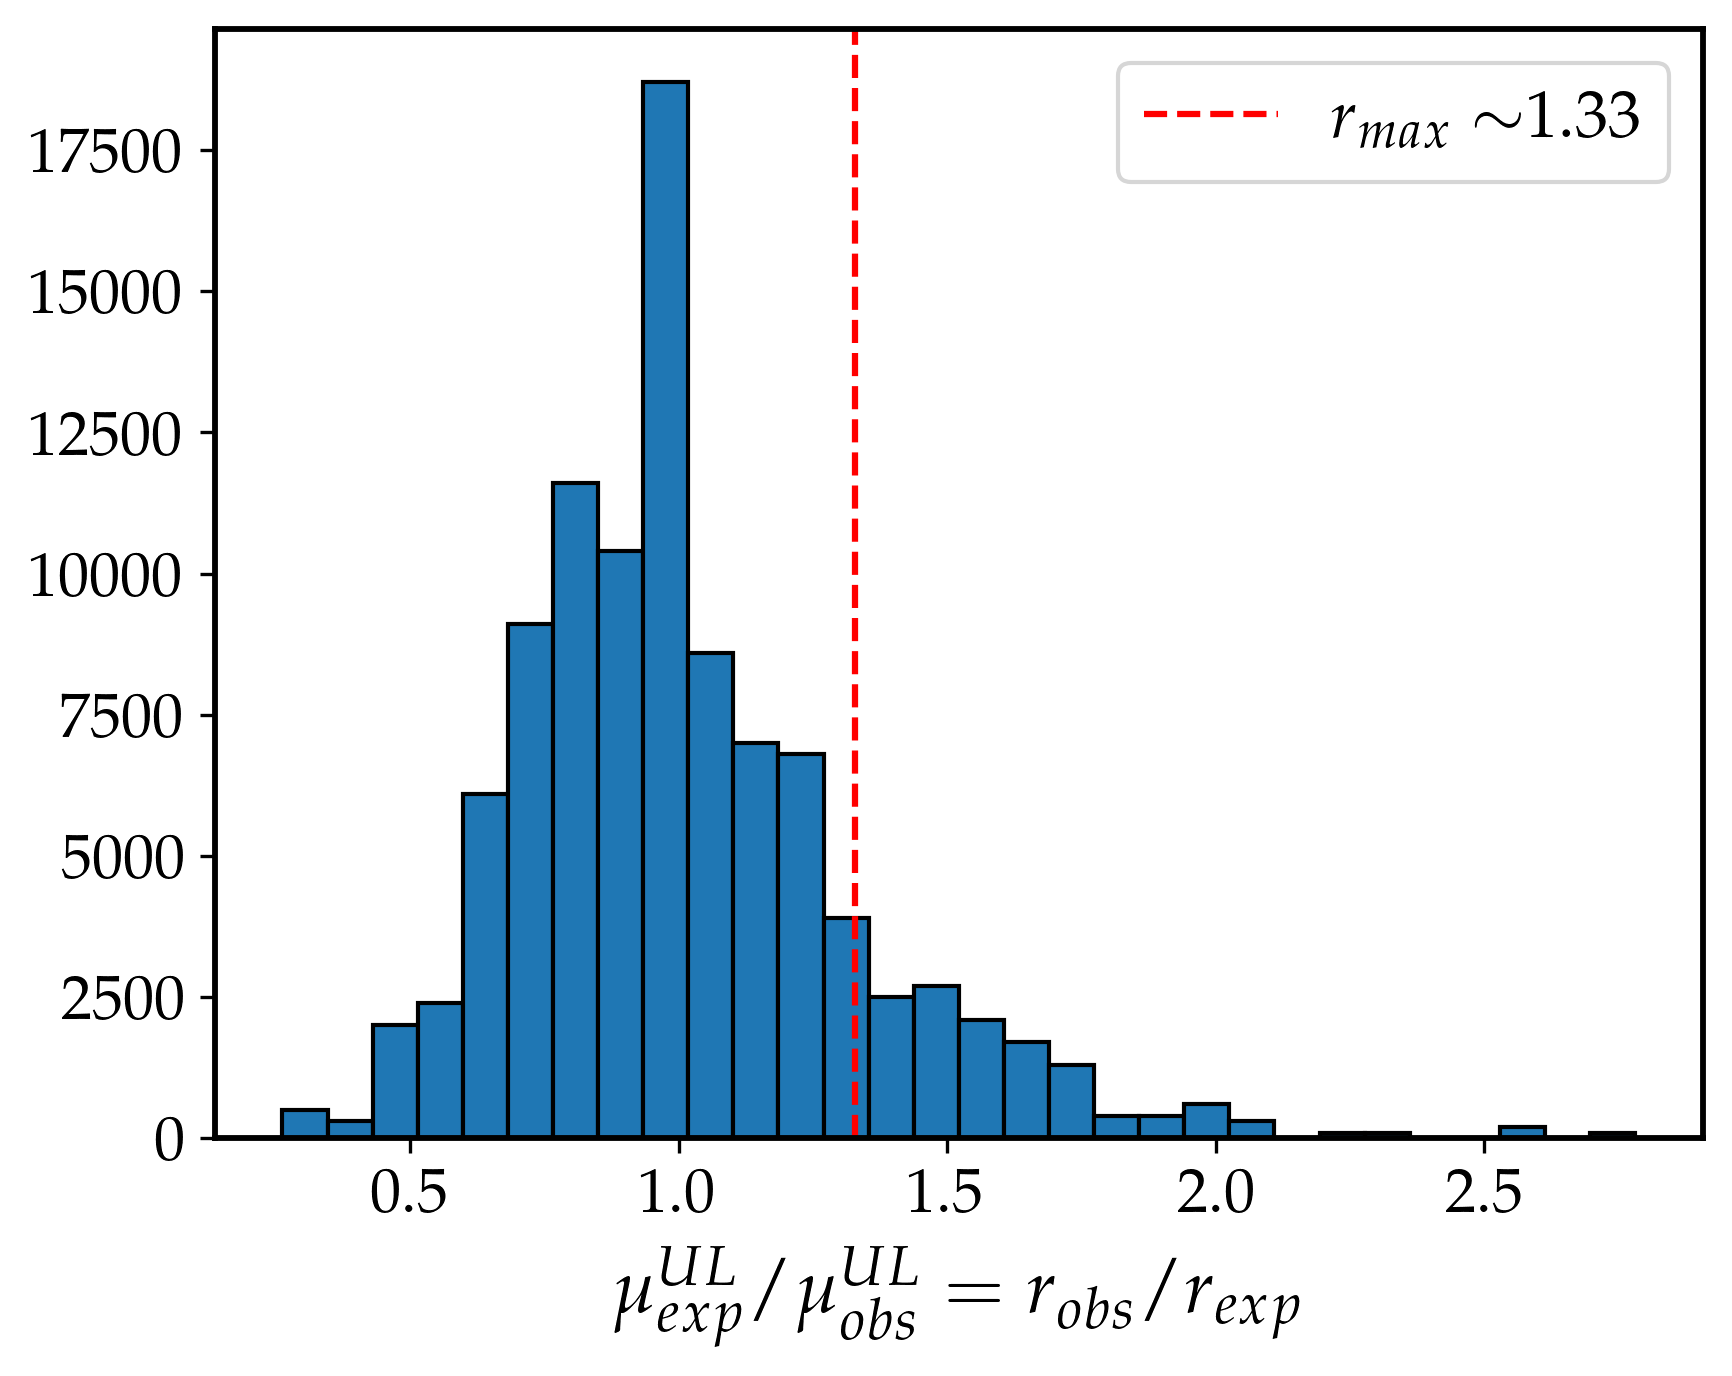

In [8]:
#plot the histogram
import numpy as np
ratio_flat = np.array(ratio_all).flatten()
dev_from_mean = np.mean(ratio_flat) + np.std(ratio_flat)
dev_from_mean_left = np.mean(ratio_flat) - np.std(ratio_flat)

plt.hist(ratio_flat, edgecolor = 'black', bins = 30)
plt.xlabel(r"$\mu^{UL}_{exp}/\mu^{UL}_{obs} = r_{obs}/r_{exp}$")
plt.axvline(x=dev_from_mean, color='red', linestyle='--', label=r'$r_{max} \sim$' + f'{round(dev_from_mean,2)}')
#plt.axvline(x=dev_from_mean_left, color='red', linestyle='--', label=rf'1 sigma dev from mean ($\sim$ {round(dev_from_mean_left,2)})')
plt.title("")
plt.legend()
plt.show()